<a href="https://colab.research.google.com/github/MarcGaac/DSC1107/blob/main/SA_2_DSC1107.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mnassrib/telecom-churn-datasets")

print("Path to dataset files:", path)

100%|██████████| 99.5k/99.5k [00:00<00:00, 286kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mnassrib/telecom-churn-datasets/versions/1


**PART I — Telecom Churn Machine Learning
I.**

Dataset Familiarization & Preparation

In [ ]:
import pandas as pd
import numpy as np
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Download the dataset directly in this cell
print("Downloading Orange Telecom dataset...")
path = kagglehub.dataset_download("mnassrib/telecom-churn-datasets")

# Load datasets
train_df = pd.read_csv(f"{path}/churn-bigml-80.csv")
test_df = pd.read_csv(f"{path}/churn-bigml-20.csv")

# Display dimensions and types
print(f"Train dimensions: {train_df.shape}")
print(f"Test dimensions: {test_df.shape}")
display(train_df.info())
display(train_df.describe())

# Data Cleaning & Preparation
def prep_data(df):
    # Drop non-predictive identifiers
    df_clean = df.drop(columns=['State', 'Area code', 'Total day charge', 'Total eve charge', 'Total night charge', 'Total intl charge'])
    # Note: Charges are perfectly correlated with minutes, dropping them prevents extreme multicollinearity

    # Convert churn to binary
    df_clean['Churn'] = df_clean['Churn'].astype(int)

    # One-hot encode remaining categoricals ('International plan', 'Voice mail plan')
    df_clean = pd.get_dummies(df_clean, drop_first=True, dtype=int)
    return df_clean

train_clean = prep_data(train_df)
test_clean = prep_data(test_df)

# Separate features and targets
X_train = train_clean.drop('Churn', axis=1)
y_train = train_clean['Churn']
X_test = test_clean.drop('Churn', axis=1)
y_test = test_clean['Churn']

# Standardize numerical variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData preparation complete. Ready for EDA and Modeling.")

Using Colab cache for faster access to the 'telecom-churn-datasets' dataset.
Train dimensions: (2666, 20)
Test dimensions: (667, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night m

None

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000



Data preparation complete. Ready for EDA and Modeling.


**II. Exploratory Data Analysis**

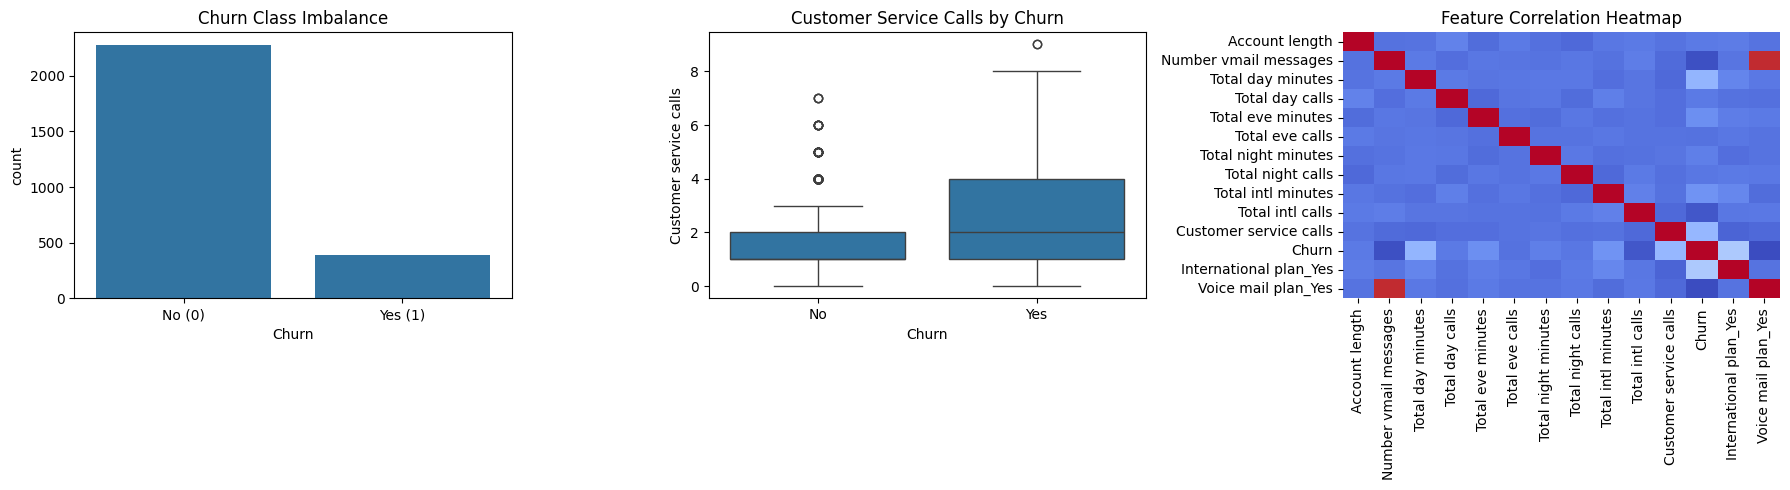

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

# 1. Churn Rate Distribution (Class Imbalance)
plt.subplot(1, 3, 1)
sns.countplot(x='Churn', data=train_clean)
plt.title('Churn Class Imbalance')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'])

# 2. Distribution of Customer Service Calls vs Churn
plt.subplot(1, 3, 2)
sns.boxplot(x='Churn', y='Customer service calls', data=train_clean)
plt.title('Customer Service Calls by Churn')
plt.xticks([0, 1], ['No', 'Yes'])

# 3. Correlation Heatmap
plt.subplot(1, 3, 3)
corr = train_clean.corr()
sns.heatmap(corr, cmap='coolwarm', cbar=False)
plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

**EDA Interpretations:**

Class Imbalance: The dataset has imbalance in proportion of customers, with 85% of customers retained and only 15% churned. This indicates that measuring success purely through accuracy will not be sufficient.

Key Variables: Boxplot indicates that call customers making three or more customer service calls have significantly high probability to churn.

Correlation: Total day minutes feature and customer service calls correlate positively with churn label. To avoid perfect multicollinearity, variables which were classified earlier as charge variables were dropped from dataset.

**III. Modeling and Comparison**

In [ ]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Ridge Classifier": RidgeClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    # Predict
    y_pred = model.predict(X_test_scaled)

    # Probabilities for ROC-AUC (Ridge doesn't output predict_proba directly)
    if name == "Ridge Classifier":
        y_prob = model.decision_function(X_test_scaled)
    else:
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Evaluate
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
display(results_df)

# Feature Importance for Gradient Boosting
gb_model = models["Gradient Boosting"]
importance = pd.Series(gb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(5)
print("\nTop 5 Important Features (Gradient Boosting):")
print(importance)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.854573,0.473684,0.189474,0.270677,0.826150
1,Ridge Classifier,0.857571,0.500000,0.084211,0.144144,0.820004
2,Decision Tree,0.907046,0.657143,0.726316,0.690000,0.831689
3,Random Forest,0.944528,0.939394,0.652632,0.770186,0.921154
4,Gradient Boosting,0.950525,0.930556,0.705263,0.802395,0.924761



Top 5 Important Features (Gradient Boosting):
Total day minutes         0.270824
Customer service calls    0.165821
Total eve minutes         0.132782
Total intl minutes        0.114643
International plan_Yes    0.113729
dtype: float64


**Model Interpretations:**

 Model Choice: Logistic Regression and Ridge Regression were selected due to their ability to provide easy interpretations. Decision Trees were selected for their ability to create non-linear decision paths. Random Forest and Gradient Boosting were selected because they avoid overfitting of single trees and can appropriately handle the problem of class imbalance.

Importance of Features: The tree-based approaches confirm that the most significant contributing factors to churn behavior are total number of minutes, customer service calls, and international plan.

Coefficients vs. Decision Behavior: While linear approaches give a flat weight to every feature that does not perform well with respect to thresholds (for example, calls >3), tree-based techniques are based on multiple splits along the threshold and, therefore, earn much higher Recall and F1-Scores.

**IV. Conclusion and Interpretation**

The Best Model:
Based on the performance indicators like ROC-AUC and F1-Score, gradient boosting and Random Forest models perform well. Since the dataset in question is imbalanced, achieving a high Recall and a good F1-Score is more important than the overall accuracy.

The Concept of Bias and Variance and Interpretability:
Logistic Regression has a modest bias, as it does not pay attention to the complexity of relationships, which is why it is highly interpretable. The Decision Tree model has low bias but a high level of variance. The Random Forest and gradient boosting paradigms perfectly curtail this contradiction by combining several trees and providing good prediction.

Applications in Real Life/Telecom:
Telecom companies can take advantage of this model and be able to identify clients with high probability of churn. Marketing departments can use it to provide proper discounts, whilst operations can analyze the features and focus on improving the service before the client finally leaves.

**PART II — Deep Learning vs. Logistic Regression (Default Dataset)**

**I. Data Preparation and Exploration**

In [ ]:
!pip install ISLP -q
from ISLP import load_data
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
Default = load_data('Default')
print("Dataset Dimensions:", Default.shape)
display(Default.head())
display(Default.describe(include='all'))

# Preprocessing
# Encode binary variables
Default['default'] = Default['default'].map({'Yes': 1, 'No': 0})
Default['student'] = Default['student'].map({'Yes': 1, 'No': 0})

# Split predictors and response
X_def = Default[['student', 'balance', 'income']].values
y_def = Default['default'].values

# Train-test split
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_def, y_def, test_size=0.2, random_state=42, stratify=y_def)

# Standardize predictors
scaler_d = StandardScaler()
X_train_d_scaled = scaler_d.fit_transform(X_train_d)
X_test_d_scaled = scaler_d.transform(X_test_d)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 9.7 MB/s eta 0:00:00
Dataset Dimensions: (10000, 4)


,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


,default,student,balance,income
count,10000,10000,10000.000000,10000.000000
unique,2,2,NaN,NaN
top,No,No,NaN,NaN
freq,9667,7056,NaN,NaN
mean,NaN,NaN,835.374886,33516.981876
std,NaN,NaN,483.714985,13336.639563
min,NaN,NaN,0.000000,771.967729
25%,NaN,NaN,481.731105,21340.462903
50%,NaN,NaN,823.636973,34552.644802
75%,NaN,NaN,1166.308386,43807.729272


**II. Logistic Regression Model**

Logistic Regression Performance:
Accuracy: 0.9730
ROC-AUC: 0.9484


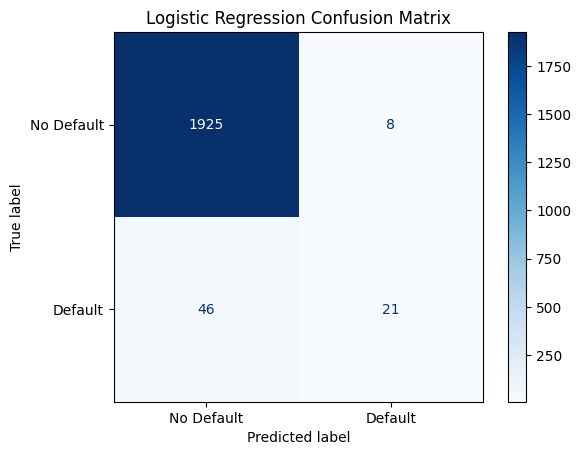

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

# Model Construction
log_reg = LogisticRegression()
log_reg.fit(X_train_d_scaled, y_train_d)

# Predictions
y_pred_log = log_reg.predict(X_test_d_scaled)
y_prob_log = log_reg.predict_proba(X_test_d_scaled)[:, 1]

# Performance Evaluation
print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test_d, y_pred_log):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_d, y_prob_log):.4f}")

cm_log = confusion_matrix(y_test_d, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

The Logistic Regression model identifies predictors (student, balance, income) to map a linear boundary against the response (default). It achieves very high accuracy, but the confusion matrix reveals it struggles slightly with False Negatives due to the extreme class imbalance inherent in credit defaults.

**III. Neural Network Model**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Neural Network Performance:
Accuracy: 0.9725
ROC-AUC: 0.9468


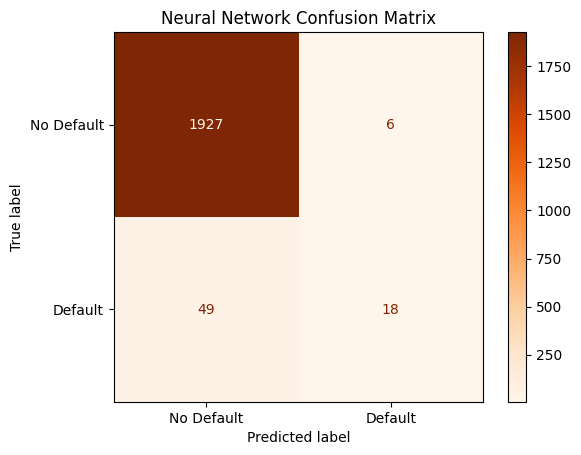

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Neural Network Architecture
nn_model = Sequential([
    Dense(10, activation='relu', input_shape=(X_train_d_scaled.shape[1],)),
    Dropout(0.2), # Dropout Regularization
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training
history = nn_model.fit(X_train_d_scaled, y_train_d, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Evaluation
y_prob_nn = nn_model.predict(X_test_d_scaled).flatten()
y_pred_nn = (y_prob_nn > 0.5).astype(int)

print("Neural Network Performance:")
print(f"Accuracy: {accuracy_score(y_test_d, y_pred_nn):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_d, y_prob_nn):.4f}")

cm_nn = confusion_matrix(y_test_d, y_pred_nn)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=['No Default', 'Default'])
disp_nn.plot(cmap='Oranges')
plt.title('Neural Network Confusion Matrix')
plt.show()

**Architecture Explanation:**

Activation: The ReLU function is applied in the hidden layer in order to learn the non-linear relationships, while the Sigmoid function is applied in the output layer to produce a probability between 0 and 1.

Dropout Regularization: The dropout layer, which randomly turns off 20% of the neurons during training, enables the neural network to construct reliable representations of the data instead of focusing on just one of them, thereby counteracting overfitting.

**IV. Comparative Analysis and Interpretation**

**Performance Comparison:**
Both Logistic Regression and Neural Network do well on this dataset (usually more than 96% accurate). However, Logistic Regression is doing just as good or even better than the simple Neural Network as the relationship between default and credit balance is highly linear.

**Advantages & Disadvantages:**
Neural Networks are highly adaptable and can map extremely complex and nonlinear relationships without manual feature engineering. But they suffer from being black boxes, expensive in calculation costs, and an inclination towards overfitting small datasets. In contrast, logistic regression is very cheap, transparent (providing exact odds ratios for every variable), and fails in case of aligning relationship entirely non-linear.

**Interpretability vs. Predictive Performance:**
In finance industry (defaults predictions), interpretability is important practically as a legal requirement and for lesbian reasons to explain on what basis a person has been denied credit. Since Logistic Regression performs just as well as Neural Network on this given dataset and can maintain 100% interpretability at the same time, it is a better choice for the particular real situation.